In [1]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
from utilities import confirm_env_variable
from utilities import get_params
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from pettingzoo.test import parallel_api_test
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import os
import torch as th
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torchrl.envs import (
    Compose,
    DoubleToFloat,
    ObservationNorm,
    StepCounter,
    TransformedEnv,
)
from tensordict.nn.distributions import NormalParamExtractor
import torch
from torch import nn
from tensordict.nn import TensorDictModule
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torch.distributions import Categorical

from torchrl.collectors import SyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (
    Compose,
    DoubleToFloat,
    ObservationNorm,
    StepCounter,
    TransformedEnv,
)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, TanhNormal, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from tqdm import tqdm
# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor, TanhNormal, Actor
from torchrl.objectives import ClipPPOLoss, ValueEstimators
import matplotlib.pyplot as plt
from torchrl.data import OneHotDiscreteTensorSpec


os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [2]:
# Devices
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 6_000  # Number of team frames collected per training iteration
n_iters = 10  # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 30  # Number of optimization steps per training iteration
minibatch_size = 400  # Size of the mini-batches in each optimization step
lr = 3e-4  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
gamma = 0.9  # discount factor
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

In [3]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [4]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])
print("[SUCCESS] Environment initiated!")

[SUCCESS] Generated 4 routes
[SUCCESS] Generated & saved 12 paths to: training_records\paths.csv
[SUCCESS] Simulator is ready to simulate!
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [1.07202881152461, 2.40890356142457, 5.089053634412728], (0, 1): [2.000480192076831, 0.7676270508203282, 0.7787715086034414], (1, 0): [0.9690442195596741, 0.6873687704023294, 1.654741781521824], (1, 1): [1.9843075459125334, 2.0852624995282487, 4.590073782015918]}

[SUCCESS] Free flow times calculated!
[INFO] Free-flow times:  {(0, 0): [1.07202881152461, 2.40890356142457, 5.089053634412728], (0, 1): [2.000480192076831, 0.7676270508203282, 0.7787715086034414], (1, 0): [0.9690442195596741, 0.6873687704023294, 1.654741781521824], (1, 1): [1.9843075459125334, 2.0852624995282487, 4.590073782015918]}
[SUCCESS] Generated agent data and saved to: training_records\agents_data.csv
[SUCCESS] Created agent objects (200)

Agent 0 has origin 0 and destination 1.


[SUCCESS] Environment initiated!


In [5]:
## https://github.com/pytorch/rl/blob/main/torchrl/envs/libs/pettingzoo.py
env = PettingZooWrapper(
    env=env,
    return_state=True,
    use_mask=True,
    group_map=None, # Use default for parallel
    categorical_actions=True,
)
print("env is: ", env)

env is:  PettingZooWrapper()


In [6]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: CompositeSpec(
    1: CompositeSpec(
        action: DiscreteTensorSpec(
            shape=torch.Size([1]),
            space=DiscreteBox(n=3),
            device=cpu,
            dtype=torch.int64,
            domain=discrete), device=cpu, shape=torch.Size([1])), device=cpu, shape=torch.Size([]))
reward_spec: CompositeSpec(
    1: CompositeSpec(
        reward: UnboundedContinuousTensorSpec(
            shape=torch.Size([1, 1]),
            space=None,
            device=cpu,
            dtype=torch.float32,
            domain=continuous), device=cpu, shape=torch.Size([1])), device=cpu, shape=torch.Size([]))
done_spec: CompositeSpec(
    done: DiscreteTensorSpec(
        shape=torch.Size([1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    terminated: DiscreteTensorSpec(
        shape=torch.Size([1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    trun

In [7]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('1', 'action')]
reward_keys: [('1', 'reward')]
done_keys: ['done', 'terminated', 'truncated', ('1', 'done'), ('1', 'terminated'), ('1', 'truncated')]


In [8]:
# This will modify the inputs and outputs of our environment in some way.
# This specific one will sum rewards over the episodes.
# We will tell the transform where where to find the reward key and where to write the summer episode reward
# The transformed environment will inherit the device and meta-data of the wrapped environment and transform these depending on the sequence of transforms it contains.
env = TransformedEnv(
    env,
    RewardSum(in_keys=[env.reward_key], out_keys=[("1", "episode_reward")]),
)

print("Environment group mapping", env.group_map)

Environment group mapping {'1': ['1']}


In [9]:
check_env_specs(env)

inside step 
next present is:  None
original is:  [0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1
 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0
 1 0 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 0]
table is:  <pandas._libs.hashtable.Int64HashTable object at 0x000001B4F0CB7CF0>
values are:  [0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1
 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0
 1 0 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 0]
uniques, codes are [0 1] [0 1 1 1 1 1 0

2024-04-15 17:28:31,052 [torchrl][INFO] check_env_specs succeeded!


after _step
self._step_proc_data


In [10]:
rollout = env.rollout(20)
print("rollout of one step:", rollout)

inside step 
next present is:  None
original is:  [0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1
 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0
 1 0 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 0]
table is:  <pandas._libs.hashtable.Int64HashTable object at 0x000001B4F0CD3060>
values are:  [0 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 0 1 1 0 0 1 1
 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 0
 1 0 0 1 0 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0
 0 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1
 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 1 1
 1 0 0 0 0 1 1 1 1 0 1 1 0 1 0 0]
uniques, codes are [0 1] [0 1 1 1 1 1 0

In [11]:
print("Shape of the rollout TensorDict:", rollout.batch_size)

Shape of the rollout TensorDict: torch.Size([1])


In [12]:
print(rollout["1"])

TensorDict(
    fields={
        action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
        done: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        episode_reward: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        mask: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        observation: Tensor(shape=torch.Size([1, 1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
        terminated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.Size([1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
    batch_size=torch.Size([1, 1]),
    device=cpu,
    is_shared=False)


In [13]:
env.action_spec[-1]

DiscreteTensorSpec(
    shape=torch.Size([]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.int64,
    domain=discrete)

In [14]:
share_parameters_policy = True

policy_net = torch.nn.Sequential(
    MultiAgentMLP(
        n_agent_inputs=env.observation_spec["1", "observation"].shape[-1],  # n_obs_per_agent
        n_agent_outputs=2 * env.action_spec.shape[-1],  # 2 * n_actions_per_agents
        n_agents=env.n_agents,
        centralised=False,  # the policies are decentralised (ie each agent will act from its observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    ),
    NormalParamExtractor(),  # this will just separate the last dimension into two outputs: a loc and a non-negative scale
)

In [15]:
for module in policy_net.modules():
    if isinstance(module, torch.nn.Linear):
        print("Weight shape:", module.weight.shape)
        print("Weight shape:", module.weight.dtype)
        print("Bias shape:", module.bias.shape)
        print("Bias shape:", module.bias.dtype)
        print("Weight values:", module.weight)
        print("Bias values:", module.bias)


Weight shape: torch.Size([256, 3])
Weight shape: torch.float32
Bias shape: torch.Size([256])
Bias shape: torch.float32
Weight values: Parameter containing:
tensor([[ 1.7123e-02, -2.3398e-01,  7.8326e-02],
        [-3.8624e-01, -3.6041e-01, -3.9509e-01],
        [-1.1884e-02, -4.8543e-01,  5.5385e-01],
        [-2.6832e-03, -2.3815e-01, -3.5147e-01],
        [-5.3736e-01,  3.9077e-01, -4.0692e-02],
        [ 3.7211e-01,  2.9205e-01,  4.0773e-01],
        [-2.0650e-01, -5.5431e-01,  3.3837e-01],
        [ 9.0572e-02,  1.1314e-01,  3.5384e-02],
        [-1.3191e-01,  8.8797e-02,  3.1937e-01],
        [-4.9672e-01, -2.4871e-01,  1.3198e-01],
        [ 1.0938e-01,  5.3167e-01,  1.3308e-01],
        [ 4.7213e-02, -6.5811e-02,  4.9546e-01],
        [ 2.8343e-01, -4.3178e-01,  7.7751e-02],
        [ 2.9630e-02,  1.5070e-01, -5.3780e-01],
        [-3.1915e-01,  2.3858e-01,  2.1883e-01],
        [ 1.9500e-01, -3.1678e-01,  2.1355e-01],
        [ 3.1092e-01, -5.7366e-01, -5.5247e-01],
        [ 4

In [16]:
env.observation_spec["1", "observation"]

BoundedTensorSpec(
    shape=torch.Size([1, 3]),
    space=ContinuousBox(
        low=Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, contiguous=True),
        high=Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, contiguous=True)),
    device=cpu,
    dtype=torch.float32,
    domain=continuous)

In [17]:
print(policy_net)

Sequential(
  (0): MultiAgentMLP(
    (agent_networks): ModuleList(
      (0): MLP(
        (0): Linear(in_features=3, out_features=256, bias=True)
        (1): Tanh()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): Tanh()
        (4): Linear(in_features=256, out_features=2, bias=True)
      )
    )
  )
  (1): NormalParamExtractor()
)


In [18]:
policy_module = TensorDictModule(
    policy_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "loc"), ("1", "scale")],
)

In [19]:
print(policy_module)

TensorDictModule(
    module=Sequential(
      (0): MultiAgentMLP(
        (agent_networks): ModuleList(
          (0): MLP(
            (0): Linear(in_features=3, out_features=256, bias=True)
            (1): Tanh()
            (2): Linear(in_features=256, out_features=256, bias=True)
            (3): Tanh()
            (4): Linear(in_features=256, out_features=2, bias=True)
          )
        )
      )
      (1): NormalParamExtractor()
    ),
    device=cpu,
    in_keys=[('1', 'observation')],
    out_keys=[('1', 'loc'), ('1', 'scale')])


In [20]:
action_spec = OneHotDiscreteTensorSpec(3)
action_spec

OneHotDiscreteTensorSpec(
    shape=torch.Size([3]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.bool,
    domain=discrete)

In [21]:
env.action_spec

DiscreteTensorSpec(
    shape=torch.Size([1]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.int64,
    domain=discrete)

In [22]:
policy = ProbabilisticActor(
    module=policy_module,
    spec=env.action_spec,
    in_keys=[("1", "loc"), ("1", "scale")],
    out_keys=[env.action_key],
    distribution_class=TanhNormal,
    return_log_prob=True,
    log_prob_key=("1", "sample_log_prob"),
)  # we'll need the log-prob for the PPO loss

In [23]:
print(policy)

ProbabilisticActor(
    module=ModuleList(
      (0): TensorDictModule(
          module=Sequential(
            (0): MultiAgentMLP(
              (agent_networks): ModuleList(
                (0): MLP(
                  (0): Linear(in_features=3, out_features=256, bias=True)
                  (1): Tanh()
                  (2): Linear(in_features=256, out_features=256, bias=True)
                  (3): Tanh()
                  (4): Linear(in_features=256, out_features=2, bias=True)
                )
              )
            )
            (1): NormalParamExtractor()
          ),
          device=cpu,
          in_keys=[('1', 'observation')],
          out_keys=[('1', 'loc'), ('1', 'scale')])
      (1): SafeProbabilisticModule()
    ),
    device=cpu,
    in_keys=[('1', 'observation')],
    out_keys=[('1', 'loc'), ('1', 'scale'), ('1', 'action'), ('1', 'sample_log_prob')])


In [24]:
print("Running policy:", policy(env.reset()))

Running policy: TensorDict(
    fields={
        1: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                loc: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                sample_log_prob: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                scale: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Si

In [25]:
share_parameters_critic = True
mappo = True  # IPPO if False

critic_net = MultiAgentMLP(
    n_agent_inputs=env.observation_spec["1", "observation"].shape[-1],
    n_agent_outputs=1,  # 1 value per agent
    n_agents=env.n_agents,
    centralised=mappo,
    share_params=share_parameters_critic,
    device=device,
    depth=2,
    num_cells=256,
    activation_class=torch.nn.Tanh,
)

critic = TensorDictModule(
    module=critic_net,
    in_keys=[("1", "observation")],
    out_keys=[("1", "state_value")],
)

In [26]:
print("Running value:", critic(env.reset()))

Running value: TensorDict(
    fields={
        1: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                state_value: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dty

In [27]:
collector = SyncDataCollector(
    env,
    policy,
    device=device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)
collector

SyncDataCollector(
    env=TransformedEnv(
        env=PettingZooWrapper(),
        transform=RewardSum(keys=[('1', 'reward')])),
    policy=ProbabilisticActor(
        module=ModuleList(
          (0): TensorDictModule(
              module=Sequential(
                (0): MultiAgentMLP(
                  (agent_networks): ModuleList(
                    (0): MLP(
                      (0): Linear(in_features=3, out_features=256, bias=True)
                      (1): Tanh()
                      (2): Linear(in_features=256, out_features=256, bias=True)
                      (3): Tanh()
                      (4): Linear(in_features=256, out_features=2, bias=True)
                    )
                  )
                )
                (1): NormalParamExtractor()
              ),
              device=cpu,
              in_keys=[('1', 'observation')],
              out_keys=[('1', 'loc'), ('1', 'scale')])
          (1): SafeProbabilisticModule()
        ),
        device=cpu,
        

In [28]:
replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(
        frames_per_batch, device=device
    ),  # We store the frames_per_batch collected at each iteration
    sampler=SamplerWithoutReplacement(),
    batch_size=minibatch_size,  # We will sample minibatches of this size
)
replay_buffer

ReplayBuffer(storage=<torchrl.data.replay_buffers.storages.LazyTensorStorage object at 0x000001B4F3982210>, sampler=<torchrl.data.replay_buffers.samplers.SamplerWithoutReplacement object at 0x000001B4F397C710>, writer=<torchrl.data.replay_buffers.writers.RoundRobinWriter object at 0x000001B4F397E150>)

In [29]:
loss_module = ClipPPOLoss(
    actor_network=policy,
    critic_network=critic,
    clip_epsilon=clip_epsilon,
    entropy_coef=entropy_eps,
    normalize_advantage=False,  # Important to avoid normalizing across the agent dimension
)
loss_module.set_keys(  # We have to tell the loss where to find the keys
    reward=env.reward_key,
    action=env.action_key,
    sample_log_prob=("1", "sample_log_prob"),
    value=("1", "state_value"),
    # These last 2 keys will be expanded to match the reward shape
    done=("1", "done"),
    terminated=("1", "terminated"),
)


loss_module.make_value_estimator(
    ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
)  # We build GAE
GAE = loss_module.value_estimator

optim = torch.optim.Adam(loss_module.parameters(), lr)

In [30]:
collector

SyncDataCollector(
    env=TransformedEnv(
        env=PettingZooWrapper(),
        transform=RewardSum(keys=[('1', 'reward')])),
    policy=ProbabilisticActor(
        module=ModuleList(
          (0): TensorDictModule(
              module=Sequential(
                (0): MultiAgentMLP(
                  (agent_networks): ModuleList(
                    (0): MLP(
                      (0): Linear(in_features=3, out_features=256, bias=True)
                      (1): Tanh()
                      (2): Linear(in_features=256, out_features=256, bias=True)
                      (3): Tanh()
                      (4): Linear(in_features=256, out_features=2, bias=True)
                    )
                  )
                )
                (1): NormalParamExtractor()
              ),
              device=cpu,
              in_keys=[('1', 'observation')],
              out_keys=[('1', 'loc'), ('1', 'scale')])
          (1): SafeProbabilisticModule()
        ),
        device=cpu,
        

In [31]:
for i, data in enumerate(collector):
    print("Got inside the loop")
    if i == 2:
        print(data)
        break

inside rollout()
before with
before the loop
0
else
else after inside if
second else
after env_input TensorDict(
    fields={
        1: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                loc: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                sample_log_prob: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
                scale: Tensor(shape=torch.Size([1, 1]), device=cpu, dty

TypeError: unhashable type: 'numpy.ndarray'

In [ ]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    tensordict_data.set(
        ("next", "1", "done"),
        tensordict_data.get(("next", "done"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    tensordict_data.set(
        ("next", "1", "terminated"),
        tensordict_data.get(("next", "terminated"))
        .unsqueeze(-1)
        .expand(tensordict_data.get_item_shape(("next", env.reward_key))),
    )
    # We need to expand the done and terminated to match the reward shape (this is expected by the value estimator)

    with torch.no_grad():
        GAE(
            tensordict_data,
            params=loss_module.critic_network_params,
            target_params=loss_module.target_critic_network_params,
        )  # Compute GAE and add it to the data

    data_view = tensordict_data.reshape(-1)  # Flatten the batch size to shuffle data
    replay_buffer.extend(data_view)

    for _ in range(num_epochs):
        for _ in range(frames_per_batch // minibatch_size):
            subdata = replay_buffer.sample()
            loss_vals = loss_module(subdata)

            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            loss_value.backward()

            torch.nn.utils.clip_grad_norm_(
                loss_module.parameters(), max_grad_norm
            )  # Optional

            optim.step()
            optim.zero_grad()

    collector.update_policy_weights_()

    # Logging
    done = tensordict_data.get(("next", "1", "done"))
    episode_reward_mean = (
        tensordict_data.get(("next", "1", "episode_reward"))[done].mean().item()
    )
    episode_reward_mean_list.append(episode_reward_mean)
    pbar.set_description(f"episode_reward_mean = {episode_reward_mean}", refresh=False)
    pbar.update()

episode_reward_mean = 0:   0%|          | 0/10 [01:38<?, ?it/s]


TypeError: unhashable type: 'numpy.ndarray'

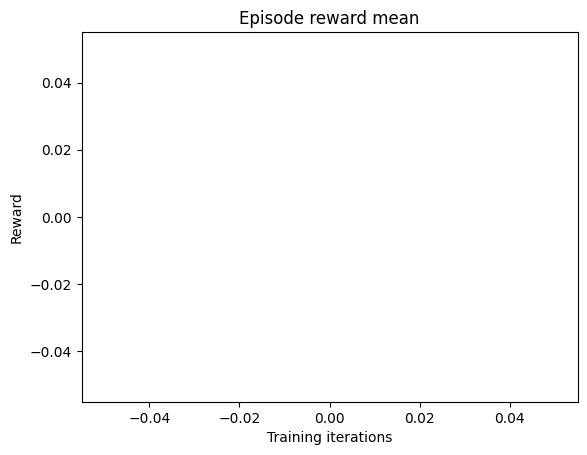

In [ ]:
plt.plot(episode_reward_mean_list)
plt.xlabel("Training iterations")
plt.ylabel("Reward")
plt.title("Episode reward mean")
plt.show()